# etree in Python: non-overlapping ellipsoid batches

[etree](https://github.com/NickAlger/ellipsoid_tree) is a header-only C++ library for
**exact** intersection tests over points, boxes, balls, ellipsoids, and simplices — with
single-pair tests, tree-accelerated queries, and tree-vs-tree sweeps — exposed to Python.
This notebook mirrors the C++
[batch-picking example](https://github.com/NickAlger/ellipsoid_tree/blob/main/docs/examples/batch_picking.md).

Install with `pip install ellipsoid-etree` (the import name is `etree`).

**Array convention:** at the Python boundary, points are *rows* — a set of `n` points in
`d` dimensions is an `(n, d)` array (scipy-style).

In [1]:
import numpy as np
import etree

## Objects and a pairwise test

Objects are built from NumPy arrays. `intersects(A, B)` is an exact overlap test
(objects are solid and closed, so merely touching counts as intersecting).

In [2]:
a = etree.Ball(np.zeros(2), 1.0)
print("r=1 balls, centers 1.5 apart:", etree.intersects(a, etree.Ball(np.array([1.5, 0.0]), 1.0)))
print("r=1 balls, centers 2.5 apart:", etree.intersects(a, etree.Ball(np.array([2.5, 0.0]), 1.0)))

r=1 balls, centers 1.5 apart: True
r=1 balls, centers 2.5 apart: False


## A family of ellipsoids

An `Ellipsoid` is `E(tau) = { x : (x - mu)^T Sigma^{-1} (x - mu) <= tau^2 }`, so a family is
given by centers `mus` (one per row) and a stack of covariance matrices `Sigmas`. Here: a
jittered 8x8 grid of thin, randomly-oriented ellipsoids, dense enough to overlap.

In [3]:
rng = np.random.default_rng(11)
mus, Sigmas = [], []
for j in range(8):
    for i in range(8):
        mus.append([i + 0.7 * rng.random(), j + 0.7 * rng.random()])
        theta = np.pi * rng.random()
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta),  np.cos(theta)]])
        semi = np.diag([(0.45 + 0.35 * rng.random()) ** 2,
                        (0.12 + 0.15 * rng.random()) ** 2])
        Sigmas.append(R @ semi @ R.T)
mus = np.array(mus)          # (64, 2): one center per row
Sigmas = np.array(Sigmas)    # (64, 2, 2): stacked covariance matrices
mus.shape, Sigmas.shape

((64, 2), (64, 2, 2))

## Partition into non-overlapping batches

`pick_ellipsoid_batches` greedily partitions the family into batches whose members are
mutually non-overlapping, considering candidates in farthest-point order so each batch
spreads across the domain. (This is the workhorse of point-spread-function probing:
impulse responses with non-overlapping supports can be probed in a single operator
application, so fewer batches means fewer applications.)

In [4]:
tree = etree.EllipsoidTree(mus, Sigmas, tau=1.0)
batches = etree.pick_ellipsoid_batches(tree)
print(f"{len(tree)} ellipsoids -> {len(batches)} non-overlapping batches")
print("batch sizes:", [len(b) for b in batches])

64 ellipsoids -> 3 non-overlapping batches
batch sizes: [45, 18, 1]


## Visualize

Each batch gets one color; within a color, no two ellipsoids overlap. `Figure` defines
`_repr_svg_`, so returning it as the last expression renders the plot inline (and GitHub
renders it in the committed notebook).

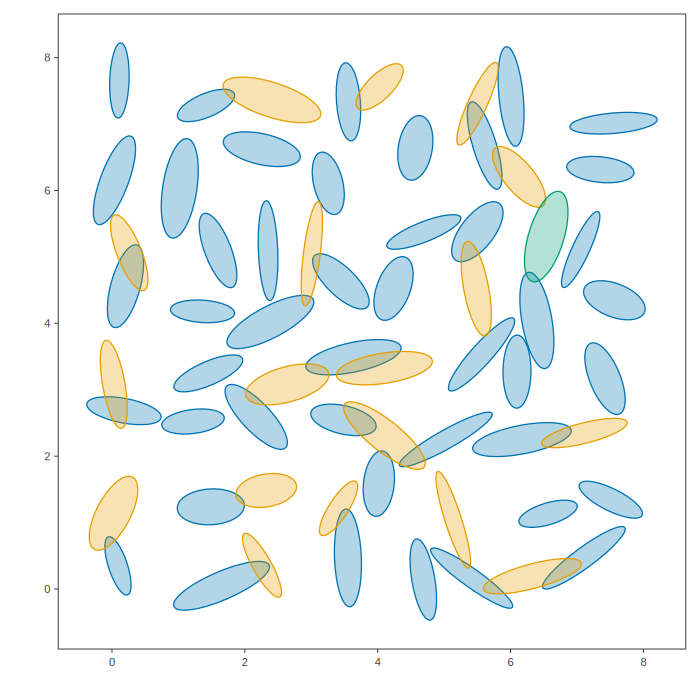

In [5]:
fig = etree.Figure()
etree.draw_batches(fig, tree, batches)
fig